# Goal -> Create and modify dataset for future use
 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded ✓")

Libraries loaded ✓


##  Load dataset

In [2]:
dt = pd.read_csv('Raw Dataset/ecommerce_sales_34500.csv')
dt

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34495,O134495,C13553,P231412,Fashion,10.44,0.20,1,Debit Card,2025-08-13,3,North,No,8.35,3.04,-0.12,23,Female
34496,O134496,C11349,P218266,Beauty,4.79,0.10,5,Debit Card,2023-12-04,6,South,Yes,21.56,3.37,6.33,61,Female
34497,O134497,C12986,P204345,Electronics,323.64,0.00,5,Credit Card,2025-02-01,6,East,No,1618.20,12.18,182.00,41,Female
34498,O134498,C17196,P217644,Home,23.09,0.05,1,Credit Card,2024-03-27,6,East,No,21.94,5.61,0.53,27,Female


In [3]:
print(f"Shape       : {dt.shape[0]:,} rows × {dt.shape[1]} columns")
print(f"Memory usage: {dt.memory_usage(deep=True).sum() / 1024:.1f} KB")
dt.head()

Shape       : 34,500 rows × 17 columns
Memory usage: 6491.0 KB


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


# Dataset overview


In [4]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  str    
 1   customer_id         34500 non-null  str    
 2   product_id          34500 non-null  str    
 3   category            34500 non-null  str    
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  str    
 8   order_date          34500 non-null  str    
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  str    
 11  returned            34500 non-null  str    
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  customer_gender

In [5]:
dt.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.00,34500.00,34500.00,34500.00,34500.00,34500.00,34500.00,34500.00
mean,119.39,0.05,1.49,4.81,170.01,6.15,28.12,43.47
std,195.62,0.07,0.93,1.24,357.50,2.39,53.35,14.98
min,1.01,0.00,1.00,3.00,0.82,0.00,-6.20,18.00
25%,16.69,0.00,1.00,4.00,19.71,4.42,1.50,31.00
50%,45.66,0.00,1.00,5.00,56.82,6.09,10.55,43.00
75%,130.95,0.10,2.00,6.00,168.53,7.83,33.13,56.00
max,2930.47,0.30,5.00,13.00,12931.80,15.65,1536.17,69.00


In [6]:
null = dt.isnull().sum()
null
print(null[null > 0] if null.sum() > 0 else "✓  No nulls found")

✓  No nulls found


In [7]:
dupli_orders = dt['order_id'] .duplicated().sum()
dupli_orders

if dupli_orders > 0:
    df = dt.drop_duplicates()
    print(f"Dropped {dupli_orders} duplicate rows → {dt.shape[0]:,} rows remain")
else:
    print("✓  No duplicates to remove")

✓  No duplicates to remove


In [8]:
dupli_rows = dt.duplicated().sum()
if dupli_rows > 0:
    df = dt.drop_duplicates()
    print(f"Dropped {dupli_rows} duplicate rows → {dt.shape[0]:,} rows remain")
else:
    print("✓  No duplicates to remove")


✓  No duplicates to remove


In [9]:
checks = {
    'quantity <= 0'    : (dt['quantity'] <= 0).sum(),
    'price <= 0'       : (dt['price'] <= 0).sum(),
    'total_amount <= 0': (dt['total_amount'] <= 0).sum(),
    'shipping_cost < 0': (dt['shipping_cost'] < 0).sum(),
}
for label, count in checks.items():
    status = "✓  OK" if count == 0 else f"⚠  {count} rows"
    print(f"{label:<25} {status}")

quantity <= 0             ✓  OK
price <= 0                ✓  OK
total_amount <= 0         ✓  OK
shipping_cost < 0         ✓  OK


# Data Cleaning


In [10]:
dt['order_date'] = pd.to_datetime(dt['order_date'])

print(f"order_date dtype : {dt['order_date'].dtype}")
print(f"Date range       : {dt['order_date'].min().date()}  →  {dt['order_date'].max().date()}")
print(f"Span             : {(dt['order_date'].max() - dt['order_date'].min()).days} days (~2 years)")

order_date dtype : datetime64[us]
Date range       : 2023-09-12  →  2025-09-11
Span             : 730 days (~2 years)


In [11]:
dt['returned'] = dt['returned'].map({'Yes': 1, 'No': 0})

return_rate = dt['returned'].mean() * 100
print(f"returned dtype  : {dt['returned'].dtype}")
print(f"Return rate     : {return_rate:.2f}%  ({dt['returned'].sum():,} of {len(dt):,} orders)")

returned dtype  : int64
Return rate     : 5.52%  (1,903 of 34,500 orders)


# Dataset Outliers

In [12]:
op = dt['profit_margin']
Q1,Q3 = op.quantile(0.25),op.quantile(0.75)
IQR = Q3 - Q1
fence = Q3 + 3* IQR # Conseravtive Upper bound


In [13]:
Outlier_count = (op>fence).sum()
Outlier_count

np.int64(1411)

In [14]:

print(f"profit_margin  →  min: {op.min():.2f}  |  median: {op.median():.2f}  |  max: {op.max():.2f}")
print(f"3× IQR fence   : {fence:.2f}")
print(f"Flagged rows   : {Outlier_count:,}  ({Outlier_count/len(dt)*100:.1f}% of dataset)")
dt['outlier'] = (dt['profit_margin'] > fence).astype(int)

profit_margin  →  min: -6.20  |  median: 10.55  |  max: 1536.17
3× IQR fence   : 128.03
Flagged rows   : 1,411  (4.1% of dataset)


In [15]:
dt['net_revenue'] = dt['total_amount'] - dt['shipping_cost']
neg_net = (dt['net_revenue'] < 0).sum()
print(f"Orders where shipping > total_amount: {neg_net}  ({neg_net/len(dt)*100:.2f}%)")
print("→ These are very small orders with standard shipping. Kept as-is.")

Orders where shipping > total_amount: 310  (0.90%)
→ These are very small orders with standard shipping. Kept as-is.


# Segementation and dates

### Month and Year extraction

In [16]:
dt['year_month'] = dt['order_date'].dt.to_period('M').astype(str)
dt['order_year']  = dt['order_date'].dt.year
dt['order_month'] = dt['order_date'].dt.month
dt

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,outlier,net_revenue,year_month,order_year,order_month
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,0,139.47,7.88,31.17,60,Female,0,131.59,2023-12,2023,12
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,0,24.73,4.60,-2.62,37,Male,0,20.13,2025-04,2025,4
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,0,166.80,6.58,13.44,34,Male,0,160.22,2024-10,2024,10
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,0,63.67,5.50,2.14,21,Female,0,58.17,2024-09,2024,9
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,0,13.88,2.74,1.15,39,Male,0,11.14,2024-12,2024,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34495,O134495,C13553,P231412,Fashion,10.44,0.20,1,Debit Card,2025-08-13,3,North,0,8.35,3.04,-0.12,23,Female,0,5.31,2025-08,2025,8
34496,O134496,C11349,P218266,Beauty,4.79,0.10,5,Debit Card,2023-12-04,6,South,1,21.56,3.37,6.33,61,Female,0,18.19,2023-12,2023,12
34497,O134497,C12986,P204345,Electronics,323.64,0.00,5,Credit Card,2025-02-01,6,East,0,1618.20,12.18,182.00,41,Female,1,1606.02,2025-02,2025,2
34498,O134498,C17196,P217644,Home,23.09,0.05,1,Credit Card,2024-03-27,6,East,0,21.94,5.61,0.53,27,Female,0,16.33,2024-03,2024,3


### Age Segementation

In [17]:
dt['age_group'] = pd.cut(
    dt['customer_age'],
    bins   = [18, 25, 35, 45, 55, 70],
    labels = ['18-24', '25-34', '35-44', '45-54', '55-69'],
    right  = True
)

dt['age_group'].value_counts()

age_group
55-69    9237
25-34    6678
35-44    6678
45-54    6609
18-24    4651
Name: count, dtype: int64

In [18]:
dt['discount_applied'] = (dt['discount'] > 0).astype(int)

In [19]:
print("New columns added:")
new_cols = ['net_revenue', 'year_month', 'order_year', 'order_month',
            'discount_applied', 'age_group', 'outlier']
for c in new_cols:
    print(f"  {c:<20} {dt[c].dtype}")

New columns added:
  net_revenue          float64
  year_month           str
  order_year           int32
  order_month          int32
  discount_applied     int64
  age_group            category
  outlier              int64


# Quick Distribution Plots

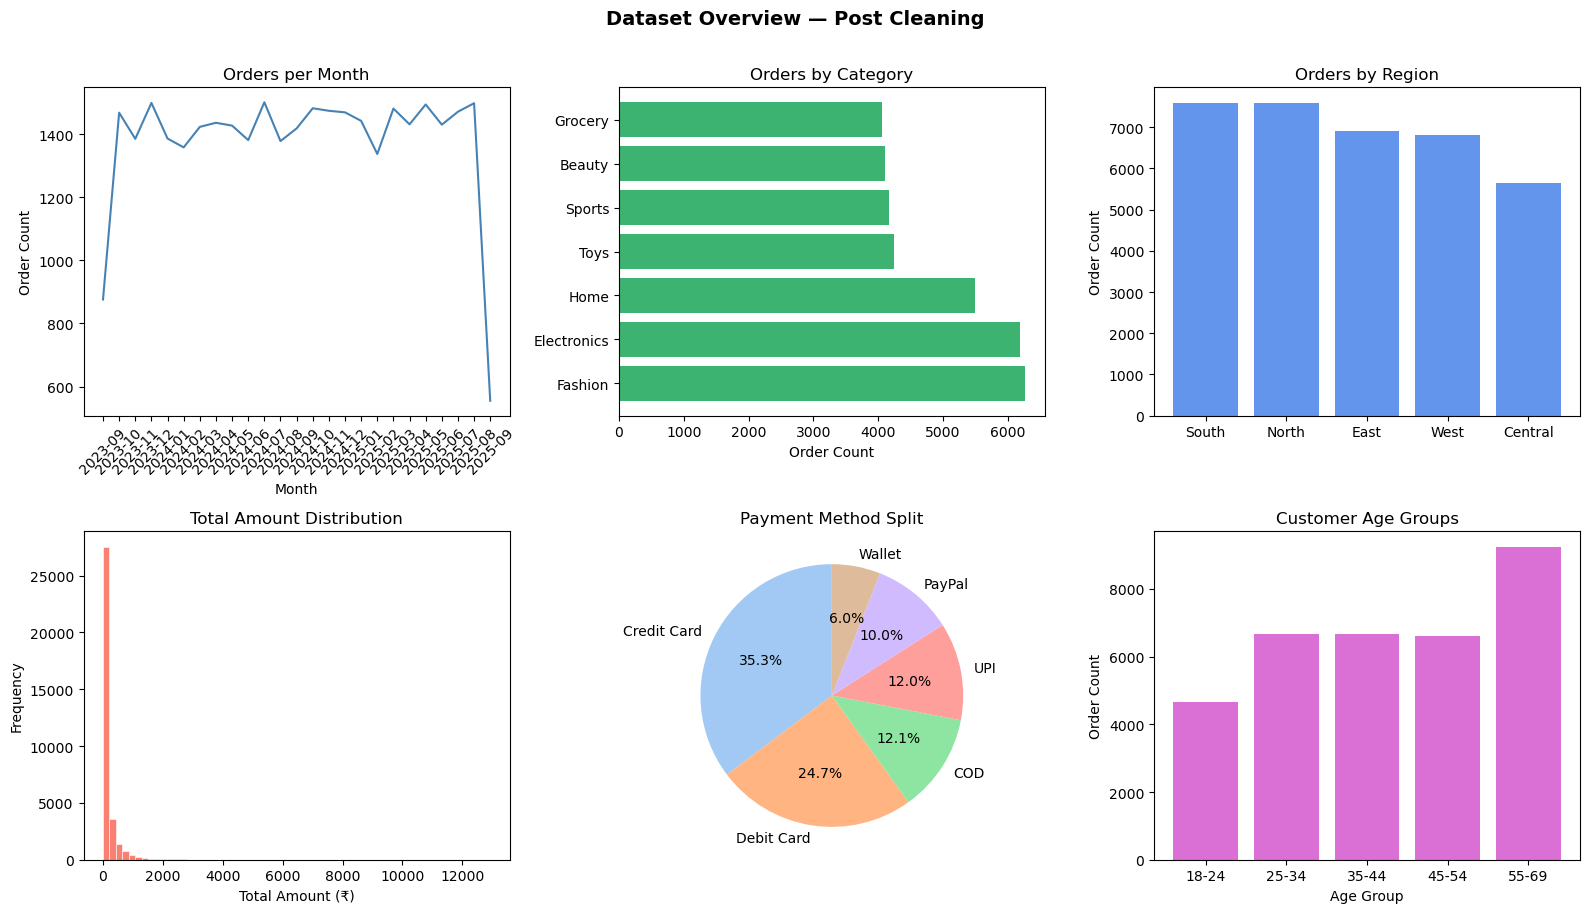

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dataset Overview — Post Cleaning', fontsize=14, fontweight='bold', y=1.01)

# 1. Orders over time
monthly = dt.groupby('year_month')['order_id'].count()
axes[0, 0].plot(monthly.index, monthly.values, linewidth=1.5, color='steelblue')
axes[0, 0].set_title('Orders per Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Order Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Category distribution
cat_counts = dt['category'].value_counts()
axes[0, 1].barh(cat_counts.index, cat_counts.values, color='mediumseagreen')
axes[0, 1].set_title('Orders by Category')
axes[0, 1].set_xlabel('Order Count')

# 3. Region distribution
region_counts = dt['region'].value_counts()
axes[0, 2].bar(region_counts.index, region_counts.values, color='cornflowerblue')
axes[0, 2].set_title('Orders by Region')
axes[0, 2].set_ylabel('Order Count')

# 4. total_amount distribution (log scale)
axes[1, 0].hist(dt['total_amount'], bins=60, color='salmon', edgecolor='white', linewidth=0.4)
axes[1, 0].set_title('Total Amount Distribution')
axes[1, 0].set_xlabel('Total Amount (₹)')
axes[1, 0].set_ylabel('Frequency')

# 5. Payment method split
op_counts = dt['payment_method'].value_counts()
axes[1, 1].pie(op_counts.values, labels=op_counts.index, autopct='%1.1f%%',
               startangle=90, colors=sns.color_palette('pastel'))
axes[1, 1].set_title('Payment Method Split')

# 6. Age group distribution
age_counts = dt['age_group'].value_counts().sort_index()
axes[1, 2].bar(age_counts.index.astype(str), age_counts.values, color='orchid')
axes[1, 2].set_title('Customer Age Groups')
axes[1, 2].set_xlabel('Age Group')
axes[1, 2].set_ylabel('Order Count')

plt.tight_layout()
plt.show()

In [21]:
print("=== CLEANED DATASET SUMMARY ===")
print(f"Rows         : {dt.shape[0]:,}")
print(f"Columns      : {dt.shape[1]}")
print(f"Nulls        : {dt.isnull().sum().sum()}")
print(f"Date range   : {dt['order_date'].min().date()} → {dt['order_date'].max().date()}")
print(f"Customers    : {dt['customer_id'].nunique():,}")
print(f"Unique orders: {dt['order_id'].nunique():,}")
print()
print("=== COLUMN DTYPES ===")
print(dt.dtypes)

=== CLEANED DATASET SUMMARY ===
Rows         : 34,500
Columns      : 24
Nulls        : 647
Date range   : 2023-09-12 → 2025-09-11
Customers    : 7,903
Unique orders: 34,500

=== COLUMN DTYPES ===
order_id                         str
customer_id                      str
product_id                       str
category                         str
price                        float64
discount                     float64
quantity                       int64
payment_method                   str
order_date            datetime64[us]
delivery_time_days             int64
region                           str
returned                       int64
total_amount                 float64
shipping_cost                float64
profit_margin                float64
customer_age                   int64
customer_gender                  str
outlier                        int64
net_revenue                  float64
year_month                       str
order_year                     int32
order_month                

In [22]:
import os

output_dir = './data'
os.makedirs(output_dir, exist_ok=True)


output_path = os.path.join(output_dir, '01_preprocessed.csv')
dt.to_csv(output_path, index=False)

print(f"✓  Saved → {output_path}")
print(f"   Shape  : {dt.shape[0]:,} rows × {dt.shape[1]} columns")
print()


✓  Saved → ./data\01_preprocessed.csv
   Shape  : 34,500 rows × 24 columns

